# 02 — Linear Control Systems and the Kalman Rank Condition

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

> **Central question.** *When can a linear system with few controls be steered between arbitrary states?*

This notebook answers the controllability question completely for linear, finite-dimensional systems: the Kalman rank condition decides it, and the controllability Gramian turns the answer into an explicit steering control.

### Table of Contents

1. **Linear control systems** — variation of constants, exact controllability, the spring–mass–damper
2. **Two first examples** — an uncontrollable system; "draw a curve, read off the control"
3. **The reachable set** — an affine subspace described by one matrix
4. **The Kalman rank condition** — the theorem, with proof, and numerical rank
5. **Genericity, robustness and numerical rank** — most systems are controllable
6. **The controllability Gramian** — the matrix that measures control
7. **An explicit steering control** — formula (G), a variational preview, and an animation
8. **Quantitative controllability** — the near-uncontrollable family E2
9. **Control ↔ ML: one system or many?**
10. **Beyond linear systems** — Nelson's car
11. **Common misconceptions**
12. **Key takeaways**
13. **Exercises**

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

torch.manual_seed(0);

In [2]:
# RK4 integrator for x' = f(t, x) along the time grid ts (derived in notebook 13; a black box here)
def odeint(f, x0, ts):
    xs = [x0]
    for t, t1 in zip(ts[:-1], ts[1:]):
        x, h = xs[-1], t1 - t
        k1 = f(t, x)
        k2 = f(t + h / 2, x + h / 2 * k1)
        k3 = f(t + h / 2, x + h / 2 * k2)
        k4 = f(t + h, x + h * k3)
        xs.append(x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4))
    return torch.stack(xs)

def lti(A, B, u):
    """Right-hand side of x' = Ax + Bu, with u an open-loop control u(t) -> R^m."""
    return lambda t, x: A @ x + B @ u(t)

def l2_effort(u, ts):
    """The L2 norm (∫|u|² dt)^{1/2} of a control along the grid ts."""
    vals = torch.stack([u(s) for s in ts])
    return float(torch.sqrt(torch.trapezoid((vals ** 2).sum(-1), ts)))

## Where are we?

[Notebook 01](01_control_fundamentals.ipynb) separated three questions: controllability (*can* we reach a target?), optimal control (which control is *best*?) and stabilization (is there a *rule* that drives the system to rest?). This notebook answers the first question completely for **linear, finite-dimensional systems**. It is the setting where everything is explicit, and every later setting is measured against it.

## 1. Linear control systems

**Idea.** Variation of constants separates what the system does alone from what the control adds.

Let $n,m\ge1$ and $T>0$. We consider

$$
x'(t)=Ax(t)+Bu(t),\quad t\in(0,T),\qquad x(0)=x^0,
$$

with $A\in\mathbb R^{n\times n}$, $B\in\mathbb R^{n\times m}$ and $x^0\in\mathbb R^n$. The state $x(t)$ has $n$ components and the control $u(t)$ has $m$. In practice $m\le n$, and often $m\ll n$: the most desirable situation is to control the system with as few controls as possible.

> **Example (the spring–mass–damper).**
> A mass $m_0$ is attached to a spring of stiffness $k$ and a damper of coefficient $c$. We measure displacement $q$ from equilibrium and apply a force $u(t)$. Newton's second law reads $m_0\ddot q = -kq - c\dot q + u$. Writing $x = (x_1, x_2)^\top$ with $x_1 = q$ the position and $x_2 = \dot q$ the velocity turns one second-order equation into two first-order ones:
> $$ \begin{bmatrix} \dot x_1 \\ \dot x_2 \end{bmatrix} = \underbrace{\begin{bmatrix} 0 & 1 \\ -\tfrac{k}{m_0} & -\tfrac{c}{m_0} \end{bmatrix}}_{A}   \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + \underbrace{\begin{bmatrix} 0 \\ \tfrac{1}{m_0} \end{bmatrix}}_{B} u . $$
> With $m_0=k=1$ and no damper, $c=0$, this is the running example **E1**, the harmonic oscillator $x_1''+x_1=u$.

**Variation of constants.** Multiply the equation by $e^{-At}$:
$$
\big(e^{-At}x(t)\big)'=e^{-At}\big(x'(t)-Ax(t)\big)=e^{-At}Bu(t).
$$
Integrating from $0$ to $t$ and multiplying by $e^{At}$ gives

$$
x(t)=e^{At}x^0+\int_0^te^{A(t-s)}Bu(s)\,ds .
\tag{VC}
$$

For every $u\in L^2(0,T;\mathbb R^m)$ this defines the unique solution, which is continuous in time with square-integrable derivative ($x\in H^1(0,T;\mathbb R^n)$).

> **Definition (exact controllability).** The system is **exactly controllable in time $T$** if for every $x^0,x^1\in\mathbb R^n$ there is $u\in L^2(0,T;\mathbb R^m)$ such that the solution satisfies $x(T)=x^1$.

The control process drives the solution from $x^0$ to $x^1$ in time $T$, by acting on the system through $u$.

**Code and plot.** Draw the mechanical system behind E1.

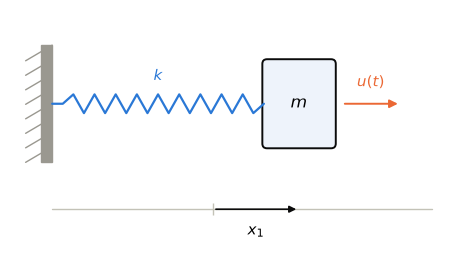

In [3]:
fig, ax = P.panels(figsize=(6.2, 2.8))
P.spring_mass_damper(ax, pos=1.1)
plt.show()

## 2. Two first examples

**Idea.** One system that cannot be controlled, and one that can — by drawing the trajectory first.

**Example 1: an uncontrollable system.** With $A=I_2$ and $B=\begin{pmatrix}1\\0\end{pmatrix}$, the system reads
$$
x_1'=x_1+u,\qquad x_2'=x_2\ \ \Longrightarrow\ \ x_2(t)=x_2^0e^t .
$$
The control does not act on the second component, which is completely determined by its initial value, so the system is not controllable.

**Example 2: the oscillator E1 is controllable.** For $x_1''+x_1=u$, a direct argument works. Choose *any* smooth curve $x_1(t)$ with the prescribed position and velocity at $t=0$ and at $t=T$, and *define* the control afterwards:
$$
u(t)=x_1''(t)+x_1(t).
$$
By construction this $u$ steers the system between the prescribed states. For instance, to stop the oscillator, from $x^0=(1,0)$ to $x^1=(0,0)$ at $T=5$, the cubic $x_1(t)=1-3(t/T)^2+2(t/T)^3$ has the right boundary values. The same argument works for every scalar equation $x^{(n)}+a_{n-1}x^{(n-1)}+\dots+a_0x=u$ (Exercise 2).

**Code and plot.** Build the control from the cubic curve and verify that it stops the oscillator.

In [4]:
A = torch.tensor([[0.0, 1.0], [-1.0, 0.0]])            # E1: x1'' + x1 = u
B = torch.tensor([[0.0], [1.0]])
T = 5.0
x0 = torch.tensor([1.0, 0.0])                          # displaced, at rest
x1 = torch.tensor([0.0, 0.0])                          # at rest at the origin
ts = torch.linspace(0, T, 2001)

# "Draw a curve, read off the control": cubic with x1(0)=1, x1'(0)=0, x1(T)=0, x1'(T)=0.
curve = lambda s: 1 - 3 * (s / T) ** 2 + 2 * (s / T) ** 3
curve_dd = lambda s: -6 / T ** 2 + 12 * s / T ** 3
u_curve = lambda s: (curve_dd(s) + curve(s)).reshape(1)          # u = x1'' + x1

x_curve = odeint(lti(A, B, u_curve), x0, ts)
print("x(T) with the curve control:", x_curve[-1].numpy().round(6),
      "   L2 effort:", round(l2_effort(u_curve, ts), 4))

x(T) with the curve control: [ 0. -0.]    L2 effort: 1.2137


## 3. The reachable set

**Idea.** Everything the control can add to the free evolution is the range of one matrix.

Is the control obtained from the cubic the *only* control that stops the oscillator? No: any other curve with the same boundary values gives another control. To organize all the possibilities, we collect the states that can be reached:

$$
\mathcal R(T,x^0)=\big\{x(T)\;:\;x\text{ solves (VC) with some }u\in L^2(0,T;\mathbb R^m)\big\}.
$$

Exact controllability means $\mathcal R(T,x^0)=\mathbb R^n$ for every $x^0$.

By (VC), $x(T)=e^{AT}x^0+L_Tu$, with the linear **input-to-state map**
$$
L_T:L^2(0,T;\mathbb R^m)\to\mathbb R^n,\qquad L_Tu=\int_0^Te^{A(T-s)}Bu(s)\,ds .
$$
So $\mathcal R(T,x^0)=e^{AT}x^0+\operatorname{Range}L_T$ is an **affine subspace**: the free evolution of $x^0$, plus everything the control can add. The key fact is that the directions the control can add are described by a single matrix.

> **Definition (Kalman matrix).** $\mathcal K(A,B)=[\,B,\;AB,\;A^2B,\;\dots,\;A^{n-1}B\,]\in\mathbb R^{n\times nm}$.

> **Theorem 1 (reachable set).** *Assumptions:* $A\in\mathbb R^{n\times n}$, $B\in\mathbb R^{n\times m}$, $T>0$.
>
> *Conclusion:* $\operatorname{Range}L_T=\operatorname{Range}\mathcal K(A,B)$. Hence
> $$\mathcal R(T,x^0)=e^{AT}x^0+\operatorname{Range}\mathcal K(A,B)\qquad\text{for every }x^0\text{ and every }T>0 .$$
>
> *Interpretation:* the reachable set is an affine subspace whose direction does not depend on $T$ or $x^0$; only its offset $e^{AT}x^0$ does.

*Proof of "$\subseteq$" (Cayley–Hamilton).* By the Cayley–Hamilton theorem, $A$ satisfies its characteristic polynomial, so $A^n$, and inductively every $A^j$ with $j\ge n$, is a linear combination of $I,A,\dots,A^{n-1}$. Hence every column of every $A^jB$ lies in $\operatorname{Range}\mathcal K$. The power series $e^{A(T-s)}B=\sum_{j\ge0}\frac{(T-s)^j}{j!}A^jB$ converges, and $\operatorname{Range}\mathcal K$ is closed, so each column of $e^{A(T-s)}B$ lies in $\operatorname{Range}\mathcal K$. Integrating against $u(s)$ keeps us there: $L_Tu\in\operatorname{Range}\mathcal K$.

The reverse inclusion "$\supseteq$" is proved in §6, with the Gramian. $\square$

**An uncontrollable example in three dimensions.** The family **E2**, studied quantitatively in §8, is
$$
A=\begin{pmatrix}0&1&0\\-1&0&0\\0&0&-1\end{pmatrix},\qquad B_\varepsilon=\begin{pmatrix}0\\1\\\varepsilon\end{pmatrix}:
$$
an oscillator coupled to a decaying mode $x_3'=-x_3+\varepsilon u$, which the actuator reaches with strength $\varepsilon$. For $\varepsilon=0$ the actuator acts only on the oscillator, and $\operatorname{Range}\mathcal K=\{x_3=0\}$. From $x^0=(0,0,1)$ the reachable set is therefore the horizontal plane $\{x_3=e^{-T}\}$, whatever the control.

**Code and plot.** Apply 60 different random controls to E2 from $x^0=(0,0,1)$ for $T=5$ and plot the endpoints $x(T)$, for $\varepsilon=0$ and for $\varepsilon=0.3$.

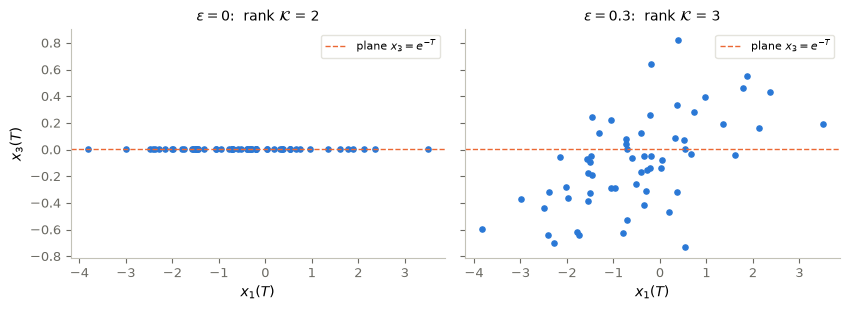

spread of x3(T) for eps = 0: 0.0   (e^-T = 0.006738 )


In [5]:
def kalman(A, B):
    """Kalman matrix [B | AB | ... | A^{n-1}B]."""
    cols = [B]
    for _ in range(A.shape[0] - 1):
        cols.append(A @ cols[-1])
    return torch.cat(cols, dim=1)

def num_rank(M):
    """Numerical rank and singular values: how many s_i exceed max(shape)·eps_mach·s_max."""
    s = torch.linalg.svdvals(M)
    return int((s > max(M.shape) * torch.finfo(M.dtype).eps * s[0]).sum()), s

def E2(eps):
    A = torch.tensor([[0.0, 1.0, 0.0], [-1.0, 0.0, 0.0], [0.0, 0.0, -1.0]])
    return A, torch.tensor([[0.0], [1.0], [eps]])

def random_control():
    c = torch.randn(4)
    return lambda s: (c[0] + c[1] * torch.sin(s) + c[2] * torch.cos(2 * s)
                      + c[3] * torch.sin(3 * s)).reshape(1)

z0 = torch.tensor([0.0, 0.0, 1.0])
ts5 = torch.linspace(0, T, 501)
controls = [random_control() for _ in range(60)]
endpoints = {eps: torch.stack([odeint(lti(*E2(eps), u), z0, ts5)[-1] for u in controls])
             for eps in (0.0, 0.3)}

fig, axes = P.panels(2, size=(4.3, 3.2), sharey=True)
for ax, (eps, E) in zip(axes, endpoints.items()):
    ax.scatter(E[:, 0], E[:, 2], s=14, color=P.BLUE)
    ax.axhline(np.exp(-T), color=P.ORANGE, lw=1, ls="--", label=r"plane $x_3=e^{-T}$")
    P.label(ax, "$x_1(T)$", "$x_3(T)$" if eps == 0 else None,
            title=rf"$\varepsilon={eps:g}$:  rank $\mathcal{{K}}$ = {num_rank(kalman(*E2(eps)))[0]}")
plt.show()
print("spread of x3(T) for eps = 0:", float(endpoints[0.0][:, 2].max() - endpoints[0.0][:, 2].min()),
      "  (e^-T =", round(float(np.exp(-T)), 6), ")")

Endpoints of E2 from $x^0=(0,0,1)$ under the same 60 random controls, projected on the $(x_1,x_3)$ plane. For $\varepsilon=0$ every endpoint has $x_3(T)=e^{-T}$, up to the integrator's tolerance: the cloud is flat, as Theorem 1 predicts. No control can change the third component, which only decays by itself. For $\varepsilon=0.3$ the same controls spread the endpoints in all directions: a small coupling is enough to turn a plane of reachable states into all of $\mathbb R^3$. How *much* control a given direction requires is the quantitative question of §8.

## 4. The Kalman rank condition

**Idea.** Controllability is a rank computation, and it never depends on the horizon.

Theorem 1 reduces controllability to linear algebra. The following classical result, due to R. E. Kalman, gives a complete answer for finite-dimensional linear systems.

> **Theorem 2 ([Kalman, 1960](https://liberzon.csl.illinois.edu/teaching/kalman_paper.pdf)).** *Assumptions:* $A\in\mathbb R^{n\times n}$, $B\in\mathbb R^{n\times m}$.
>
> *Conclusion:* the system $x'=Ax+Bu$ is exactly controllable in some time $T>0$ if and only if
> $$\operatorname{rank}\,[\,B,\,AB,\,\dots,\,A^{n-1}B\,]=n .$$
> Consequently, if it is controllable in some time $T>0$, it is controllable in **every** time $T>0$.
>
> *Interpretation:* controllability is an algebraic property of the pair $(A,B)$ and does not depend on the horizon. How *expensive* control is does depend on $T$ (§8).

*Proof.* **Necessity.** If $\operatorname{rank}\mathcal K<n$, Theorem 1 ("$\subseteq$", already proved) gives $\mathcal R(T,x^0)\subseteq e^{AT}x^0+\operatorname{Range}\mathcal K\ne\mathbb R^n$, for every $T$: the system is not controllable.

**Sufficiency.** Assume $\operatorname{rank}\mathcal K=n$, and let $v\in\mathbb R^n$ be orthogonal to $\operatorname{Range}L_T$. We show $v=0$, so that $\operatorname{Range}L_T=\mathbb R^n$.

For every control, $0=\langle v,L_Tu\rangle=\int_0^T\big\langle B^*e^{A^*(T-s)}v,\,u(s)\big\rangle\,ds$. Choosing $u(s)=B^*e^{A^*(T-s)}v$ gives $\int_0^T|B^*e^{A^*(T-s)}v|^2\,ds=0$. The integrand is continuous, so
$$
g(s):=B^*e^{A^*(T-s)}v=0\qquad\text{for all }s\in[0,T].
$$
The function $g$ is analytic and vanishes identically, so all its derivatives vanish. At $s=T$, $g^{(j)}(T)=(-1)^jB^*(A^*)^jv=0$ for all $j\ge0$. In other words, $v$ is orthogonal to every column of $A^jB$, hence to $\operatorname{Range}\mathcal K=\mathbb R^n$, and $v=0$.

**Independence of $T$.** The rank condition does not involve $T$. $\square$

The function $g(s)=B^*e^{A^*(T-s)}v$ that appeared in the proof will be given a name, and a meaning, in [notebook 03](03_observability_duality_adjoints.ipynb).

**Numerical rank.** In computations, "rank" means *numerical* rank: the number of singular values above a tolerance. We use the standard rule $\text{tol}=\max(\text{shape})\cdot\varepsilon_{\rm mach}\cdot s_{\max}$ (`num_rank` above), in double precision. The tolerance is a numerical decision, not a theorem: singular values close to it deserve a closer look (§5).

**Code and plot.** Compute the rank and the singular values of $\mathcal K$ for five pairs $(A,B)$.

In [6]:
tensors = lambda *rows: torch.tensor(rows, dtype=torch.float64)
A64, B64 = A.double(), B.double()
A4 = torch.block_diag(A64, A64)                        # two identical oscillators ...
B4 = tensors([0.0], [1.0], [0.0], [1.0])               # ... driven by the same input

examples = {
    "Example 1: A = I, B = e1": (torch.eye(2, dtype=torch.float64), tensors([1.0], [0.0])),
    "E1 oscillator": (A64, B64),
    "E2, eps = 0": (E2(0.0)[0].double(), E2(0.0)[1].double()),
    "E2, eps = 0.1": (E2(0.1)[0].double(), E2(0.1)[1].double()),
    "two identical oscillators, one input": (A4, B4),
}
print(f"{'pair (A, B)':38s} n   rank K   singular values of K")
for name, (A_, B_) in examples.items():
    r, s = num_rank(kalman(A_, B_))
    print(f"{name:38s} {A_.shape[0]}   {r:4d}     {np.array2string(s.numpy(), precision=3)}")

# The untouchable direction of the two identical oscillators: q = "x1 - x3"
q = tensors(1.0, 0.0, -1.0, 0.0)
print("\nq^T A^k B for k = 0..3:",
      [round(float(q @ torch.linalg.matrix_power(A4, k) @ B4), 12) for k in range(4)])

pair (A, B)                            n   rank K   singular values of K
Example 1: A = I, B = e1               2      1     [1.414 0.   ]
E1 oscillator                          2      2     [1. 1.]
E2, eps = 0                            3      2     [1.414 1.    0.   ]
E2, eps = 0.1                          3      3     [1.414 1.005 0.141]
two identical oscillators, one input   4      2     [2.000e+00 2.000e+00 2.009e-16 2.276e-34]

q^T A^k B for k = 0..3: [0.0, 0.0, 0.0, 0.0]


The two uncontrollable cases are of different kinds. In Example 1 and in E2 at $\varepsilon=0$, a mode is simply not connected to the input. In the case of *two identical oscillators driven by the same input*, both oscillators are connected, but they respond identically, so no control can move them independently: the rank is 2, not 4, and the difference of positions $q=(1,0,-1,0)$ satisfies $q^\top A^kB=0$ for every $k$ — it is untouchable. For E2 at $\varepsilon=0.1$ the rank is full, but one singular value is small. This is the difference between the algebraic answer and the quantitative one, the subject of §8.

## 5. Genericity, robustness and numerical rank

**Idea.** Almost every pair $(A,B)$ is controllable — but "controllable" can still be nearly uncontrollable.

**Controllable pairs are open and dense.** Controllability fails exactly when all $n\times n$ minors of $\mathcal K(A,B)$ vanish. Each minor is a polynomial in the entries of $(A,B)$. The set where finitely many polynomials vanish, not all of them identically zero, is closed and has empty interior. So controllability is **robust**: it survives small perturbations of $A$ and $B$. And it is **generic**: most systems are controllable, and an arbitrarily small perturbation makes an uncontrollable pair controllable. (In the robustness statement, controllability is a property of the *model*; it should not be confused with generalization in machine learning, a different notion met in [notebook 09](09_machine_learning_foundations_generalization.ipynb).)

**Cost estimate.** When controllability holds, there is a control with $\|u\|_{L^2(0,T)}\le C\,|e^{AT}x^0-x^1|$, where $C$ depends on $(A,B,T)$. The size of $C$ is the quantitative side of controllability. The Gramian of §6 makes it computable.

**Rank is not a reliable measure of "how controllable".** By genericity, a random pair is controllable with probability one *if its entries have a joint distribution that is absolutely continuous with respect to Lebesgue measure* on the space of pairs $(A,B)$: the uncontrollable pairs form a proper algebraic subset, of Lebesgue measure zero. This fails for other distributions, for instance integer-valued or sparse entries, which can put positive probability on uncontrollable pairs. But a pair can be controllable *and* nearly uncontrollable, as E2 at $\varepsilon=0.1$ in the table above. Its numerical rank is full only because $\sqrt2\,\varepsilon$ is far above the tolerance. For $\varepsilon$ near $10^{-15}$ the numerical rank would drop to 2, although the algebraic rank is 3. The singular values tell more than the rank.

## 6. The controllability Gramian

**Idea.** Applying the input-to-state map to the controls from the proof produces one matrix that decides everything.

The proof of Theorem 2 used the control $u(s)=B^*e^{A^*(T-s)}v$. Applying $L_T$ to controls of this form produces a matrix.

> **Definition (controllability Gramian).** $\displaystyle\mathcal G_T=\int_0^Te^{A(T-s)}BB^*e^{A^*(T-s)}\,ds\in\mathbb R^{n\times n}.$

> **Proposition 3 (properties of the Gramian).**
> 1. $\mathcal G_T$ is symmetric and positive semidefinite: $v^*\mathcal G_Tv=\int_0^T|B^*e^{A^*(T-s)}v|^2ds\ge0$.
> 2. $\ker\mathcal G_T=(\operatorname{Range}\mathcal K)^\perp$.
> 3. $\mathcal G_T$ is invertible if and only if $\operatorname{rank}\mathcal K=n$, that is, if and only if the system is controllable.
> 4. $L_T\big(B^*e^{A^*(T-\cdot)}c\big)=\mathcal G_Tc$ for every $c\in\mathbb R^n$.

*Proof.* (1) Symmetry is clear from the formula, and the identity follows from $v^*e^{A(T-s)}BB^*e^{A^*(T-s)}v=|B^*e^{A^*(T-s)}v|^2$.

(2) $\mathcal G_Tv=0$ implies $v^*\mathcal G_Tv=0$, hence $g(s)=B^*e^{A^*(T-s)}v\equiv0$, and the derivative argument in the proof of Theorem 2 gives $v\perp\operatorname{Range}\mathcal K$. Conversely, if $v\perp\operatorname{Range}\mathcal K$, then $v$ is orthogonal to every column of $e^{A(T-s)}B$ by the Cayley–Hamilton step of Theorem 1. So $g\equiv0$, and $\mathcal G_Tv=\int_0^Te^{A(T-s)}B\,g(s)\,ds=0$.

(3) follows from (2). (4) is the definition of $L_T$ applied to $u(s)=B^*e^{A^*(T-s)}c$. $\square$

**End of the proof of Theorem 1 ("$\supseteq$").** By (4), $\operatorname{Range}L_T\supseteq\operatorname{Range}\mathcal G_T$. By (2), and since $\mathcal G_T$ is symmetric, $\operatorname{Range}\mathcal G_T=(\ker\mathcal G_T)^\perp=\operatorname{Range}\mathcal K$. $\square$

## 7. An explicit steering control

**Idea.** Solve one $n\times n$ linear system, and the control is a formula.

If the system is controllable, property (4) tells us how to reach any target. We want $L_Tu=x^1-e^{AT}x^0$; try $u=B^*e^{A^*(T-\cdot)}c$ and solve $\mathcal G_Tc=x^1-e^{AT}x^0$:

$$
\boxed{\;u(t)=B^*e^{A^*(T-t)}\,\mathcal G_T^{-1}\big(x^1-e^{AT}x^0\big).\;}
\tag{G}
$$

*Verification.* By (VC) and the definition of $\mathcal G_T$,
$$
x(T)=e^{AT}x^0+\int_0^Te^{A(T-s)}BB^*e^{A^*(T-s)}\,ds\;\mathcal G_T^{-1}\big(x^1-e^{AT}x^0\big)=e^{AT}x^0+\big(x^1-e^{AT}x^0\big)=x^1 .
$$

We now compute (G) for E1, stopping the oscillator from $x^0=(1,0)$ at $T=5$, as in §2, and compare it with the control obtained from the cubic curve. Both stop the oscillator exactly — which one needs less $L^2$ effort?

**Code and plot.** Implement the Gramian and formula (G) right under their definitions, steer E1, and compare the two controls.

Kalman matrix K = [B, AB] =
 [[0. 1.]
 [1. 0.]]
Gramian G_T =
 [[2.63599 0.45974]
 [0.45974 2.364  ]]
symmetric: True    eigenvalues: [2.02057 2.97943]



|x(T) - x1| with the Gramian control (G): 9.4e-06
L2 effort: Gramian control 0.6266   vs   cubic-curve control 1.2137


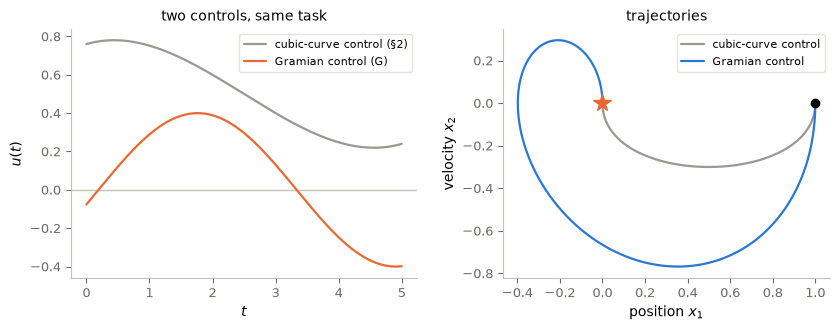

In [7]:
def gramian(A, B, T, n_quad=400):
    """G_T = ∫_0^T e^{A(T-s)} B Bᵀ e^{Aᵀ(T-s)} ds, by the trapezoid rule (τ = T - s)."""
    taus = torch.linspace(0, T, n_quad + 1)
    integrand = torch.stack([(E := torch.matrix_exp(A * tau)) @ B @ B.T @ E.T for tau in taus])
    return torch.trapezoid(integrand, taus, dim=0)

class GramianControl:
    """The steering control (G): u(t) = Bᵀ e^{Aᵀ(T-t)} G_T⁻¹ (x¹ - e^{AT} x⁰)."""
    def __init__(self, A, B, x0, x1, T):
        self.A, self.B, self.T = A, B, T
        self.G = gramian(A, B, T)
        self.d = x1 - torch.matrix_exp(A * T) @ x0
        self.c = torch.linalg.solve(self.G, self.d)
    def __call__(self, t):
        return self.B.T @ torch.matrix_exp(self.A.T * (self.T - t)) @ self.c
    def effort(self):                                  # (∫|u|² dt)^{1/2} = (dᵀ G_T⁻¹ d)^{1/2}
        return float(torch.sqrt(self.d @ self.c))

G = gramian(A, B, T)
print("Kalman matrix K = [B, AB] =\n", kalman(A, B).numpy())
print("Gramian G_T =\n", G.numpy().round(5))
print("symmetric:", bool(torch.allclose(G, G.T)), "   eigenvalues:",
      np.round(torch.linalg.eigvalsh(G).numpy(), 5))

u_G = GramianControl(A, B, x0, x1, T)
x_G = odeint(lti(A, B, u_G), x0, ts)
print(f"\n|x(T) - x1| with the Gramian control (G): {float((x_G[-1] - x1).norm()):.1e}")
print(f"L2 effort: Gramian control {u_G.effort():.4f}   vs   cubic-curve control {l2_effort(u_curve, ts):.4f}")

fig, (ax1, ax2) = P.panels(2, size=(4.3, 3.4))
P.curves(ax1, ts, {"cubic-curve control (§2)": (torch.stack([u_curve(s) for s in ts])[:, 0], P.GREY),
                   "Gramian control (G)": (torch.stack([u_G(s) for s in ts])[:, 0], P.ORANGE)},
         xlabel="$t$", ylabel="$u(t)$", zero="h", title="two controls, same task")
P.phase(ax2, [x_curve, x_G], labels=["cubic-curve control", "Gramian control"],
        colors=[P.GREY, P.BLUE], start=x0, target=x1, equal=True,
        xlabel="position $x_1$", ylabel="velocity $x_2$", title="trajectories")
plt.show()

Both controls do the job exactly, so they are two points of the affine set of all controls described in §3. The Gramian control needs about half the $L^2$ effort of the curve control. It is also a pure sinusoid at the oscillator's own frequency. Neither fact has been explained yet; we return to them at the end of the notebook.

**Code and animation.** The same task seen as a film: the free oscillator never settles, while the Gramian control brings the mass to rest at the origin at $T=5$.

In [8]:
x_free = odeint(lti(A, B, lambda t: torch.zeros(1)), x0, ts)
idx = torch.arange(0, len(ts), 40)                     # ~50 frames
pf, pc = x_free[idx, 0].numpy(), x_G[idx, 0].numpy()

fig, (axm, axt) = P.panels(1, 2, ratios=[1.1, 1], figsize=(6.4, 4.6))
up_free = P.spring_mass_artist(axm, 0.8, P.GREY, "no control")
up_ctrl = P.spring_mass_artist(axm, -0.8, P.BLUE, "control (G)")
axm.plot(0.0, -0.8, "*", color=P.ORANGE, ms=14, zorder=0)
P.label(axm, xlim=(-3.0, 2.3), ylim=(-1.8, 1.8), equal=True, off=True)

axt.plot(ts, x_free[:, 0], color=P.GREY, lw=1.2)
axt.plot(ts, x_G[:, 0], color=P.BLUE, lw=1.5)
axt.plot(T, 0.0, "*", color=P.ORANGE, ms=12)
cursor = axt.axvline(0, color=P.ORANGE, lw=1)
P.label(axt, "$t$", "$x_1$", xlim=(0, T))

def update(i):
    up_free(pf[i]); up_ctrl(pc[i]); cursor.set_xdata([ts[idx[i]]] * 2)

P.animate(fig, update, len(idx), interval=60)

### 7.1 A variational preview: least energy via a Lagrange multiplier

*Optional. Notebook 03 re-derives this properly, through duality.*

Among all controls achieving the displacement $d=x^1-e^{AT}x^0$, look for the one of least energy, $J(u)=\tfrac12\int_0^T\|u(s)\|^2ds$. With a Lagrange multiplier $\lambda\in\mathbb R^n$ for the terminal constraint,

$$ \mathcal L(u,\lambda)=\tfrac12\int_0^T\!u^\top u\,ds+\lambda^\top\Big(\int_0^T\!e^{A(T-s)}Bu(s)\,ds-d\Big). $$

Stationarity in $u$, pointwise in $s$, gives $u(s)=-B^*e^{A^*(T-s)}\lambda$. Substituting into the constraint gives $d=-\mathcal G_T\lambda$, so $\lambda=-\mathcal G_T^{-1}d$ and the stationary control is exactly **(G)**, with

$$ \int_0^T\|u(s)\|^2ds=d^\top\mathcal G_T^{-1}d . $$

The energy $d^\top\mathcal G_T^{-1}d$ is the honest price of the manoeuvre: directions in which $\mathcal G_T$ is nearly singular are the expensive ones, even when the rank test formally passes — this is exactly what §8 measures. (That the stationary point is a *minimum* is proved in notebook 03.)

> **Remark (no minimum manoeuvre time).** Controllability holds for **every** horizon $T>0$, however small: a linear system has no minimum manoeuvre time. It pays for haste in energy instead, since $\mathcal G_T^{-1}$ blows up as $T\to0$ (Exercise 5).

## 8. Quantitative controllability: the near-uncontrollable family E2

**Idea.** The rank is a yes/no answer; the Gramian prices every direction.

The Kalman condition is a yes/no answer. Notebook 01 showed with damping that "yes" can hide very different behaviours. Here is the analogue for controllability, on the family E2 of §3:
$$
A=\begin{pmatrix}0&1&0\\-1&0&0\\0&0&-1\end{pmatrix},\qquad B_\varepsilon=\begin{pmatrix}0\\1\\\varepsilon\end{pmatrix}.
$$
A direct computation gives $\det\mathcal K(A,B_\varepsilon)=-2\varepsilon$, so the pair is controllable for every $\varepsilon\ne0$.

Using (G), the $L^2$ effort of that control for a displacement $d=x^1-e^{AT}x^0$ is $\big(d^*\mathcal G_T^{-1}d\big)^{1/2}$. We compare two targets reached from $x^0=0$: the **oscillator direction** $e_1$ and the **weak mode** $e_3$. As $\varepsilon\to0$, what happens to the smallest singular value of $\mathcal K$, to the smallest eigenvalue of $\mathcal G_T$, and to the two efforts?

**Code and plot.** Sweep $\varepsilon$ from $10^{-3}$ to $1$ on log–log axes.

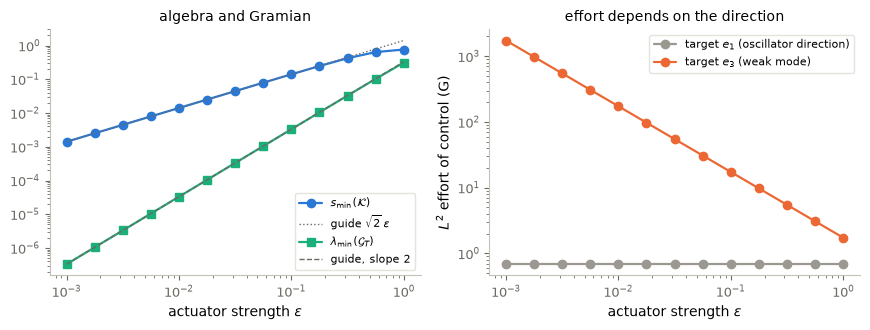

rank of K for every eps in the sweep: [3]


In [9]:
epsilons = np.logspace(-3, 0, 13)
targets = {"$e_1$ (oscillator direction)": torch.tensor([1.0, 0.0, 0.0]),
           "$e_3$ (weak mode)": torch.tensor([0.0, 0.0, 1.0])}
s_min, lam_min = [], []
effort = {name: [] for name in targets}
for eps in epsilons:
    A2, B2 = E2(float(eps))
    G2 = gramian(A2, B2, T)
    s_min.append(float(num_rank(kalman(A2, B2))[1][-1]))
    lam_min.append(float(torch.linalg.eigvalsh(G2)[0]))
    for name, d in targets.items():
        effort[name].append(float(torch.sqrt(d @ torch.linalg.solve(G2, d))))

fig, (ax1, ax2) = P.panels(2, size=(4.4, 3.4))
ax1.loglog(epsilons, s_min, "o-", color=P.BLUE, label=r"$s_{\min}(\mathcal{K})$")
ax1.loglog(epsilons, np.sqrt(2) * epsilons, ":", color=P.NOTE, lw=1, label=r"guide $\sqrt{2}\,\varepsilon$")
ax1.loglog(epsilons, lam_min, "s-", color=P.AQUA, label=r"$\lambda_{\min}(\mathcal{G}_T)$")
ax1.loglog(epsilons, lam_min[0] * (epsilons / epsilons[0]) ** 2, "--", color=P.NOTE, lw=1,
           label="guide, slope 2")
P.label(ax1, r"actuator strength $\varepsilon$", title="algebra and Gramian")
for (name, values), color in zip(effort.items(), (P.GREY, P.ORANGE)):
    ax2.loglog(epsilons, values, "o-", color=color, label=f"target {name}")
P.label(ax2, r"actuator strength $\varepsilon$", r"$L^2$ effort of control (G)",
        title="effort depends on the direction")
plt.show()
print("rank of K for every eps in the sweep:",
      sorted({num_rank(kalman(*E2(float(e))))[0] for e in epsilons}))

The rank stays 3 throughout, so the algebraic answer is always "controllable". But $s_{\min}(\mathcal K)$ decays like $\varepsilon$ and $\lambda_{\min}(\mathcal G_T)$ like $\varepsilon^2$. The effort to reach the weak mode $e_3$ grows like $1/\varepsilon$, while the effort to reach the oscillator direction $e_1$ **does not change at all**. Control becomes expensive *in difficult directions*, not for every target. [Notebook 03](03_observability_duality_adjoints.ipynb) explains where these rates come from and why the Gramian control is the natural one to measure.

> **Remark (what E2 does not show).** At $\varepsilon=0$, E2 loses controllability, but its uncontrollable mode $x_3'=-x_3$ is *stable*: it decays by itself. Losing controllability is therefore not the same as losing the ability to stabilize. For instance, the feedback $u=-B_0^*x$ gives the closed-loop eigenvalues $(-1\pm i\sqrt3)/2$ and $-1$. Stabilization is studied in [notebook 05](05_feedback_stabilization.ipynb).

### 8.1 Why these curves?

*Optional.*

*The effort to reach $e_1$ is independent of $\varepsilon$.* A control steers $0$ to $e_1$ if and only if the oscillator part ends at $(1,0)$ and $x_3(T)=\varepsilon\int_0^Te^{-(T-s)}u(s)\,ds=0$. For $\varepsilon\ne0$ the second condition is $\int_0^Te^{-(T-s)}u\,ds=0$, which does not involve $\varepsilon$. The set of admissible controls, and hence the least effort among them, is the same for every $\varepsilon\ne0$. (That the control (G) attains this least effort is shown in notebook 03.)

*The effort to reach $e_3$ scales exactly like $1/\varepsilon$.* Now the oscillator part must end at $0$, a homogeneous condition, and $\varepsilon\int_0^Te^{-(T-s)}u\,ds=1$. Writing $u=v/\varepsilon$, the conditions on $v$ do not involve $\varepsilon$, so every admissible $u$ is $1/\varepsilon$ times an admissible $v$ for $\varepsilon=1$, and the *least* effort scales exactly like $1/\varepsilon$. The same holds for control (G), because notebook 03 proves it is the least-effort control; notebook 03 also computes the constant.

*$s_{\min}(\mathcal K)\approx\sqrt2\,\varepsilon$* (a standard perturbation fact). $\mathcal K(A,B_\varepsilon)=\mathcal K_0+\varepsilon E$ with $\mathcal K_0=\mathcal K(A,B_0)$ of rank 2. For a simple zero singular value with unit right and left null vectors $v$ and $w$ of $\mathcal K_0$, $s_{\min}(\mathcal K_0+\varepsilon E)=\varepsilon\,|w^*Ev|+O(\varepsilon^2)$. Here $v=(1,0,1)/\sqrt2$, $w=e_3$ and $E=e_3\,(1,-1,1)$, so $w^*Ev=\sqrt2$.

## 9. Control ↔ ML: one system or many?

**Idea.** Supervised learning turns the controllability question around.

Classical controllability asks whether **one system** can be steered by **its control**: the Kalman theorem answers how many states $n$ a few controls $m$ can handle. In the machine-learning part of the course the question is turned around. Supervised learning is read as **simultaneous** (ensemble) control: *many* trajectories, one per data point, steered by *one shared* control, the parameters of the network. The rank argument of this notebook does not apply there, and different, geometric constructions are needed (notebook 14).

## 10. Beyond linear systems

*Optional.*

For nonlinear systems, controllability can come from *combining* motions rather than from a rank test on $(A,B)$. The classical illustration is **Nelson's car**: two controls, steering and driving, suffice to control a four-dimensional state, consisting of the position, the orientation of the car and the angle of the wheels — the mathematics of the parking manoeuvre. Behind it is the theory of Lie brackets (see [Sontag](https://doi.org/10.1007/978-1-4612-0577-7) or [Coron](https://doi.org/10.1090/surv/136)). It reappears, in a different form, in the classification results of notebook 14.

## 11. Common misconceptions

**"With fewer controls than states, a system cannot be controllable."** E1 has one control and two states, and it is controllable. What matters is how $A$ propagates the action of $B$, which is exactly what $\mathcal K$ records.

**"Controllability in a longer time is easier, so it can hold for large $T$ and fail for small $T$."** For linear systems the property does not depend on $T$ (Theorem 2). The *cost* of control does depend on $T$.

**"Full rank means control is easy."** E2 has full rank for every $\varepsilon>0$, yet some targets become very expensive (§8). The rank is an algebraic yes/no; the Gramian measures the difficulty.

**"Uncontrollable means unstable."** E2 at $\varepsilon=0$ is uncontrollable, but its uncontrollable mode decays by itself (§8).

**"The control that reaches the target is unique."** The set of controls is an affine space (§3). The figure of §7 shows two different controls for the same task.

## 12. Key takeaways

1. Variation of constants: $x(T)=e^{AT}x^0+L_Tu$ with $L_Tu=\int_0^Te^{A(T-s)}Bu(s)\,ds$.
2. Reachable set: $\mathcal R(T,x^0)=e^{AT}x^0+\operatorname{Range}\mathcal K(A,B)$, an affine subspace whose direction does not depend on $T$.
3. Kalman: controllable ⟺ $\operatorname{rank}[B,AB,\dots,A^{n-1}B]=n$; and then controllable in every time $T>0$.
4. The proof uses Cayley–Hamilton (necessity) and the vanishing of all derivatives of $B^*e^{A^*(T-s)}v$ at $s=T$ (sufficiency).
5. Gramian: $\mathcal G_T$ is symmetric, positive semidefinite, with $\ker\mathcal G_T=(\operatorname{Range}\mathcal K)^\perp$; it is invertible iff the system is controllable.
6. Formula (G) steers $x^0$ to $x^1$ exactly, with effort $\big(d^*\mathcal G_T^{-1}d\big)^{1/2}$ for the displacement $d=x^1-e^{AT}x^0$.
7. The rank is algebraic; singular values and Gramian eigenvalues measure how hard control is, direction by direction.

## 13. Exercises

★ conceptual · ★★ mathematical · ★★★ computational

1. **Predict the rank. ★** *Without computing*, predict whether each pair is controllable, then check with the `kalman` and `num_rank` code above: (a) the double integrator $A=\begin{pmatrix}0&1\\0&0\end{pmatrix}$, $B=\begin{pmatrix}0\\1\end{pmatrix}$; (b) $A=\operatorname{diag}(1,2)$, $B=\begin{pmatrix}1\\1\end{pmatrix}$; (c) $A=I_2$, $B=\begin{pmatrix}1\\1\end{pmatrix}$; (d) $A=\operatorname{diag}(1,2)$, $B=\begin{pmatrix}1\\0\end{pmatrix}$.
2. **Scalar equations of order $n$. ★★** Write $x^{(n)}+a_{n-1}x^{(n-1)}+\dots+a_1x'+a_0x=u$ as a first-order system for $(x,x',\dots,x^{(n-1)})$ (companion form). Show that $\mathcal K(A,B)$ is triangular with nonzero diagonal, so the system is controllable with a single control, whatever the coefficients.
3. **Reachable sets. ★★** (a) For Example 1 ($A=I_2$, $B=e_1$), describe $\mathcal R(T,x^0)$ explicitly as a set in the plane, and say how it moves as $T$ grows. (b) For a general pair, show that $\mathcal R(T,x^0)=\mathcal R(T,y^0)$ if and only if $e^{AT}(x^0-y^0)\in\operatorname{Range}\mathcal K$, and interpret this for E2 at $\varepsilon=0$.
4. **The Cayley–Hamilton step. ★★** (a) Show that $\operatorname{Range}\mathcal K(A,B)$ is the smallest $A$-invariant subspace containing the columns of $B$. (b) Deduce that $\operatorname{span}\{A^jB\text{ columns}:j\ge0\}=\operatorname{Range}\mathcal K$. (c) Show that if $\operatorname{rank}\mathcal K<n$, there is $v\ne0$ with $v^*e^{tA}B=0$ for all $t\in\mathbb R$, and explain why this makes $\langle v,x(t)\rangle$ independent of the control.
5. **The Gramian grows with $T$. ★★** (a) Show that $T\mapsto\mathcal G_T$ is non-decreasing: $\mathcal G_{T'}-\mathcal G_T$ is positive semidefinite for $T'>T$. (b) Deduce that $\lambda_{\min}(\mathcal G_T)$ is non-decreasing in $T$. (c) Using the effort formula $\big(d^*\mathcal G_T^{-1}d\big)^{1/2}$ of §8, show that the control (G) needs no more effort for a longer horizon, for the same displacement $d$. Why is this the same $d$ for E1 only when $x^0=0$?
6. **Two almost identical oscillators. ★★★** Two oscillators with frequencies $1$ and $1+\delta$ are driven by the same input: $A=\operatorname{diag}(A_{\rm osc},A_{1+\delta})$ with $A_\omega=\begin{pmatrix}0&1\\-\omega^2&0\end{pmatrix}$, and $B=(0,1,0,1)^\top$. For $\delta=0$ the pair is uncontrollable (§4). For $\delta\in\{1,0.3,0.1,0.03,0.01\}$ and $T=5$, compute $s_{\min}(\mathcal K)$, $\lambda_{\min}(\mathcal G_T)$, and the effort of (G) to stop the first oscillator from $(1,0)$ while keeping the second at rest, i.e. $x^0=(1,0,0,0)$, $x^1=0$. Plot them against $\delta$ and guess the rates. What does this mean for an engineer who must control two nearly identical machines with one signal?

In [10]:
# TODO: student exercise (Exercise 6)
# Build A(delta) and B, then compute s_min(K), lambda_min(G_T) and the effort of (G)
# for x0 = (1, 0, 0, 0), x1 = 0, T = 5, for each delta. Plot against delta on log-log axes.

def two_oscillators(delta):
    ...  # your code here
    return None

## Where are we going?

We now know **when** a linear system is controllable (Kalman), and we have an **explicit** control (G) that steers any $x^0$ to any $x^1$. Three questions remain open, and the figure of §7 makes them concrete.

- **Why does this particular control arise?** We guessed the form $u=B^*e^{A^*(T-\cdot)}c$ from the proof of Theorem 2. Is there a principle behind it?
- **Why is it better than the others?** In §7 it needed about half the effort of the curve control. Is it the *cheapest* control of all?
- **Why does the function $B^*e^{A^*(T-s)}v$ keep appearing?** It looks like the solution of an equation running *backward* from $t=T$.

[Notebook 03](03_observability_duality_adjoints.ipynb) answers all three. That function is the observation of an **adjoint system**, the control (G) is the minimizer of a dual problem and the control of minimum $L^2$ norm, and controllability turns out to be equivalent to *observability* of the adjoint.

## References

1. R. E. Kalman, [*Contributions to the theory of optimal control*](https://liberzon.csl.illinois.edu/teaching/kalman_paper.pdf), Boletín de la Sociedad Matemática Mexicana **5** (1960), 102–119.
2. E. D. Sontag, [*Mathematical Control Theory: Deterministic Finite Dimensional Systems*](https://doi.org/10.1007/978-1-4612-0577-7), 2nd ed., Springer, 1998.
3. J.-M. Coron, [*Control and Nonlinearity*](https://doi.org/10.1090/surv/136), Mathematical Surveys and Monographs **136**, AMS, 2007.
4. E. Zuazua, [*Controllability and observability of partial differential equations: some results and open problems*](https://doi.org/10.1016/S1874-5717(07)80010-7), Handbook of Differential Equations: Evolutionary Equations, Vol. 3, North-Holland, 2007, 527–621.